<a href="https://colab.research.google.com/github/nalarratih/UAS-Kalkulus-Integral-Kelompok6/blob/main/UAS_KalkulusIntegral_Kelompok6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Bagian A: Deskripsi Masalah dan Satuan**
Sebuah kendaraan bergerak di jalan tol selama T = 100 detik. Pergerakan dibagi menjadi 4 fase, yaitu:

- Fase 1 interval waktu (0 ≤ t ≤ 25 s): Akselerasi Linier — v(t) = 2t
- Fase 2 interval waktu (25 < t ≤ 50 s): Konstan — v(t) = 50
- Fase 3 interval waktu (50 < t ≤ 75 s): Akselerasi Kuadratik — v(t) = 50 + (1/25)(t−50)²
- Fase 4 interval waktu  (75 < t ≤ 100 s): Deselerasi Linier — v(t) = 75 − 3(t−75)

Satuan
- Waktu (t) = detik (s)
- Kecepatan v(t) = meter/detik (m/s)
- Jarak/Akumulasi (s)= meter (m)

### Tujuan
Untuk menghitung jarak tempuh total dengan 2 pendekatan, yaitu analitik (SymPy) dan numerik (NumPy trapesium), disertai validasi dan visualisasi per fasenya.

## **Bagian B: Model Matematis**
Fungsi Kecepatan Piecewise v(t)
$$v(t) = \begin{cases} 2t & 0 \leq t \leq 25 \quad\text{(Fase 1: Akselerasi Linier)}\\ 50 & 25 < t \leq 50 \quad\text{(Fase 2: Konstan)}\\ 50 + 0{,}04(t-50)^2 & 50 < t \leq 75 \quad\text{(Fase 3: Akselerasi Kuadratik)}\\ 75 - 3(t-75) & 75 < t \leq 100 \quad\text{(Fase 4: Deselerasi Linier)} \end{cases}$$


Integral Tentu per Fase

$$s_1 = \int_0^{25} 2t\,dt$$

$$ s_2 = \int_{25}^{50} 50\,dt$$

$$s_3 = \int_{50}^{75}\left[50+0{,}04(t-50)^2\right]dt$$

$$s_4 = \int_{75}^{100}\left[75-3(t-75)\right]dt$$

$$s_{\text{total}} = s_1 + s_2 + s_3 + s_4$$

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

## **Bagian C: Solusi Simbolik (SymPy)**


In [ ]:
sp.init_printing(use_unicode=True)

# Definisi simbol
t = sp.Symbol('t', real=True)

# Batas fase
t0, t1, t2, t3, t4 = 0, 25, 50, 75, 100

# Fungsi simbolik per fase
v1_sym = 2 * t                                    # 0 - 25
v2_sym = sp.Integer(50)                           # 25 - 50
v3_sym = 50 + sp.Rational(1, 25) * (t - 50)**2   # 50 - 75
v4_sym = 75 - 3 * (t - 75)                       # 75 - 100

print('=' * 55)
print('FUNGSI KECEPATAN SIMBOLIK PER FASE')
print('=' * 55)

print(f'v1(t) = {v1_sym}      , {t0} <= t <= {t1}')
print(f'v2(t) = {v2_sym}      , {t1} < t <= {t2}')
print(f'v3(t) = {v3_sym}      , {t2} < t <= {t3}')
print(f'v4(t) = {v4_sym}      , {t3} < t <= {t4}')


FUNGSI KECEPATAN SIMBOLIK PER FASE
v1(t) = 2*t      , 0 <= t <= 25
v2(t) = 50      , 25 < t <= 50
v3(t) = (t - 50)**2/25 + 50      , 50 < t <= 75
v4(t) = 300 - 3*t      , 75 < t <= 100


In [ ]:
# Integral simbolik per fase
s1_sym = sp.integrate(v1_sym, (t, t0, t1))
s2_sym = sp.integrate(v2_sym, (t, t1, t2))
s3_sym = sp.integrate(v3_sym, (t, t2, t3))
s4_sym = sp.integrate(v4_sym, (t, t3, t4))

s_total_sym = s1_sym + s2_sym + s3_sym + s4_sym

print('=' * 55)
print('HASIL INTEGRAL SIMBOLIK (JARAK PER FASE)')
print('=' * 55)
print(f'  s1  (Fase 1 — Akselerasi)     = {s1_sym} m')
print(f'  s2  (Fase 2 — Konstan)        = {s2_sym} m')
print(f'  s3  (Fase 3 — Aksel. Kuadrat) = {s3_sym} m')
print(f'  s4  (Fase 4 — Deselerasi)     = {s4_sym} m')
print('-' * 55)
print(f'  s_total (Simbolik)            = {s_total_sym} m')

HASIL INTEGRAL SIMBOLIK (JARAK PER FASE)
  s1  (Fase 1 — Akselerasi)     = 625 m
  s2  (Fase 2 — Konstan)        = 1250 m
  s3  (Fase 3 — Aksel. Kuadrat) = 4375/3 m
  s4  (Fase 4 — Deselerasi)     = 1875/2 m
-------------------------------------------------------
  s_total (Simbolik)            = 25625/6 m


In [ ]:
print('=== VERIFIKASI SIMBOLIK (diff dari antiturunan) ===')
# perulangan untuk setiap fase gerakan
for i, (v_sym_i, a, b) in enumerate(
    [(v1_sym, t0, t1), (v2_sym, t1, t2), (v3_sym, t2, t3), (v4_sym, t3, t4)], start=1):
    F = sp.integrate(v_sym_i, t)  # Menghitung antiturunan
    check = sp.simplify(sp.diff(F, t) - v_sym_i)  # Menurunkan kembali hasil integral
    print(f'  Fase {i}: turunan antiturunan - v{i}(t) = {check} --> OK = {check == 0}')

=== VERIFIKASI SIMBOLIK (diff dari antiturunan) ===
  Fase 1: turunan antiturunan - v1(t) = 0  --> OK = True
  Fase 2: turunan antiturunan - v2(t) = 0  --> OK = True
  Fase 3: turunan antiturunan - v3(t) = 0  --> OK = True
  Fase 4: turunan antiturunan - v4(t) = 0  --> OK = True


## Bagian D: Solusi Numerik (NumPy) — 2 Resolusi Sampling

In [ ]:
# Fungsi kecepatan numerik piecewise
def v_num(t_arr):
    """Hitung v(t) untuk setiap titik dalam array t_arr."""
    v = np.zeros_like(t_arr, dtype=float)
    m1 = (t_arr >= t0) & (t_arr <= t1)
    v[m1] = 2 * t_arr[m1]                        # Fase 1: 0-25
    m2 = (t_arr > t1) & (t_arr <= t2)
    v[m2] = 50.0                                  # Fase 2: 25-50
    m3 = (t_arr > t2) & (t_arr <= t3)
    v[m3] = 50 + (1/25) * (t_arr[m3] - 50)**2   # Fase 3: 50-75
    m4 = (t_arr > t3) & (t_arr <= t4)
    v[m4] = 75 - 3 * (t_arr[m4] - 75)            # Fase 4: 75-100
    return v

def trapz_per_fase(n):
    """Jarak per fase & total dengan metode trapesium, resolusi n."""
    hasil = {}
    batas = [(t0, t1), (t1, t2), (t2, t3), (t3, t4)]
    for i, (a, b) in enumerate(batas, start=1):
        tt = np.linspace(a, b, n + 1)
        vv = v_num(tt)
        hasil[f's{i}'] = np.trapezoid(vv, tt)
    hasil['total'] = sum(hasil[f's{i}'] for i in range(1, 5))
    return hasil

# Dua resolusi
hasil_n1000   = trapz_per_fase(n=1_000)
hasil_n100000 = trapz_per_fase(n=100_000)

print('=' * 60)
print('HASIL NUMERIK — METODE TRAPESIUM')
print('=' * 60)
print(f"{'':6} {'n=1.000':>14} {'n=100.000':>14}")
print('-' * 40)
for i in range(1, 5):
    key = f's{i}'
    print(f'  {key}    {hasil_n1000[key]:>14.6f}   {hasil_n100000[key]:>14.6f}  m')
print('-' * 40)
print(f"  Total {hasil_n1000['total']:>14.6f}   {hasil_n100000['total']:>14.6f}  m")


HASIL NUMERIK — METODE TRAPESIUM
              n=1.000      n=100.000
----------------------------------------
  s1        625.000000       625.000000  m
  s2       1250.000000      1250.000000  m
  s3       1458.333437      1458.333333  m
  s4        937.500000       937.500000  m
----------------------------------------
  Total    4270.833437      4270.833333  m


## Bagian E: Validasi — Simbolik vs Numerik + Error Analysis

In [ ]:
s_sym_vals = {
    's1': float(s1_sym), 's2': float(s2_sym),
    's3': float(s3_sym), 's4': float(s4_sym),
    'total': float(s_total_sym)
}

print('=' * 78)
print('TABEL VALIDASI: SIMBOLIK vs NUMERIK')
print('=' * 78)
print(f"{'':6} {'Simbolik':>11} {'Num n=1K':>13} {'Num n=100K':>13} {'ErrAbs n=1K':>13} {'ErrAbs n=100K':>14}")
print('-' * 78)

for key in ['s1', 's2', 's3', 's4', 'total']:
    sv  = s_sym_vals[key]
    nv1 = hasil_n1000[key]
    nv2 = hasil_n100000[key]
    e1  = abs(sv - nv1)
    e2  = abs(sv - nv2)
    lbl = 'TOTAL' if key == 'total' else key.upper()
    print(f'  {lbl:<6} {sv:>11.4f} {nv1:>13.6f} {nv2:>13.6f} {e1:>13.2e} {e2:>14.2e}')

print('=' * 78)

rel1 = abs(s_sym_vals['total'] - hasil_n1000['total'])   / s_sym_vals['total'] * 100
rel2 = abs(s_sym_vals['total'] - hasil_n100000['total'])  / s_sym_vals['total'] * 100
print(f'\nError Relatif Total (n=1.000)   : {rel1:.6f} %')
print(f'Error Relatif Total (n=100.000) : {rel2:.6f} %')
print()
print('Sumber selisih:')
print('  Metode trapesium mengaproksimasi luasan dengan trapezoid kecil.')
print('  Semakin besar n, semakin halus diskretisasi dan semakin kecil error.')

TABEL VALIDASI: SIMBOLIK vs NUMERIK
          Simbolik      Num n=1K    Num n=100K   ErrAbs n=1K  ErrAbs n=100K
------------------------------------------------------------------------------
  S1        625.0000    625.000000    625.000000      0.00e+00       1.14e-13
  S2       1250.0000   1250.000000   1250.000000      0.00e+00       0.00e+00
  S3       1458.3333   1458.333437   1458.333333      1.04e-04       1.04e-08
  S4        937.5000    937.500000    937.500000      0.00e+00       1.14e-13
  TOTAL    4270.8333   4270.833437   4270.833333      1.04e-04       1.04e-08

Error Relatif Total (n=1.000)   : 0.000002 %
Error Relatif Total (n=100.000) : 0.000000 %

Sumber selisih:
  Metode trapesium mengaproksimasi luasan dengan trapezoid kecil.
  Semakin besar n, semakin halus diskretisasi dan semakin kecil error.


## Bagian F: Visualisasi Kurva v(t) dan Area per Fase

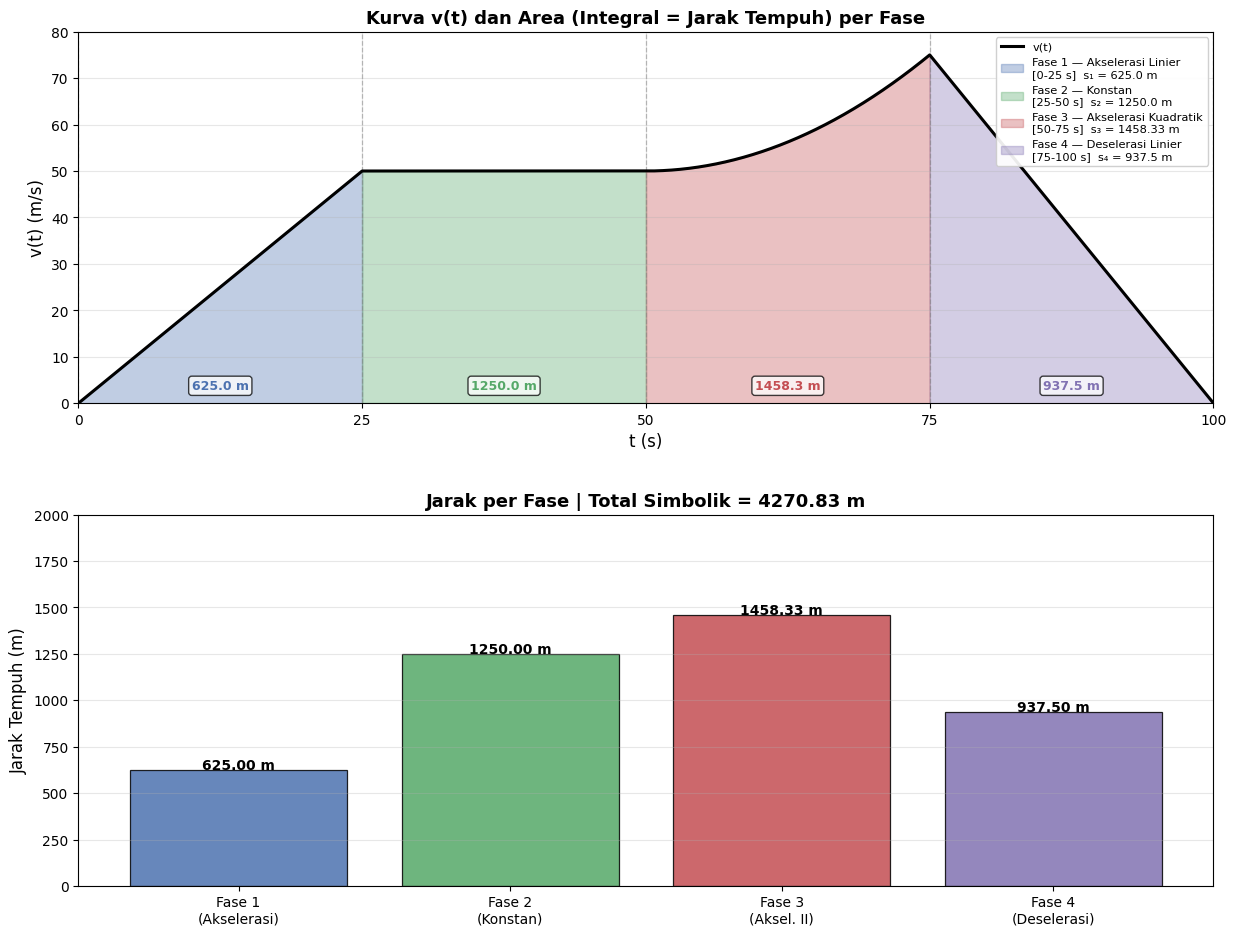

Plot tersimpan sebagai 'visualisasi_kecepatan_fase.png'


In [ ]:
# ─── 4) Visualisasi — mengikuti pola template ──────────────

def plot_velocity_and_area(t0_val, t4_val, n=2000):
    """
    Plot kurva v(t) dan area (integral) per fase.
    Parameter
    ---------
    t0_val  : batas waktu awal (s)
    t4_val  : batas waktu akhir (s)
    n       : jumlah titik sampling
    """

    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

    batas = [(t0, t1), (t1, t2), (t2, t3), (t3, t4)]

    s_vals = [
        float(s1_sym),
        float(s2_sym),
        float(s3_sym),
        float(s4_sym)
    ]

    labels = [
        f'Fase 1 — Akselerasi Linier\n[{t0}-{t1} s]  s₁ = {s_vals[0]:.1f} m',
        f'Fase 2 — Konstan\n[{t1}-{t2} s]  s₂ = {s_vals[1]:.1f} m',
        f'Fase 3 — Akselerasi Kuadratik\n[{t2}-{t3} s]  s₃ = {s_vals[2]:.2f} m',
        f'Fase 4 — Deselerasi Linier\n[{t3}-{t4} s]  s₄ = {s_vals[3]:.1f} m',
    ]

    tt_all = np.linspace(t0_val, t4_val, n + 1)
    vv_all = v_num(tt_all)

    fig, axes = plt.subplots(2, 1, figsize=(13, 10))

    # ── Plot atas: kurva v(t) + area per fase ──────────────

    ax1 = axes[0]

    ax1.plot(
        tt_all,
        vv_all,
        'k-',
        linewidth=2.2,
        zorder=5,
        label='v(t)'
    )

    for (a, b), color, lbl in zip(batas, colors, labels):

        tt_f = np.linspace(a, b, n // 4 + 1)
        vv_f = v_num(tt_f)

        ax1.fill_between(
            tt_f,
            vv_f,
            alpha=0.35,
            color=color,
            label=lbl
        )

        ax1.axvline(
            x=a,
            color='gray',
            linestyle='--',
            linewidth=0.9,
            alpha=0.5
        )

    ax1.axvline(
        x=t4_val,
        color='gray',
        linestyle='--',
        linewidth=0.9,
        alpha=0.5
    )

    centers = [(a + b) / 2 for a, b in batas]

    for cx, sv, col in zip(centers, s_vals, colors):

        ax1.text(
            cx,
            3,
            f'{sv:.1f} m',
            ha='center',
            fontsize=9,
            color=col,
            fontweight='bold',
            bbox=dict(
                boxstyle='round,pad=0.25',
                fc='white',
                alpha=0.75
            )
        )

    ax1.set_xlabel('t (s)', fontsize=12)
    ax1.set_ylabel('v(t) (m/s)', fontsize=12)

    ax1.set_title(
        'Kurva v(t) dan Area (Integral = Jarak Tempuh) per Fase',
        fontsize=13,
        fontweight='bold'
    )

    ax1.legend(
        loc='upper right',
        fontsize=8.2,
        framealpha=0.92
    )

    ax1.set_xlim(t0_val, t4_val)
    ax1.set_xticks([0, 25, 50, 75, 100])

    ax1.set_ylim(0, 80)
    ax1.set_yticks(np.arange(0, 81, 10))

    ax1.grid(True, alpha=0.3)

    # ── Plot bawah: bar chart jarak per fase ───────────────

    ax2 = axes[1]

    fase_lbl = [
        'Fase 1\n(Akselerasi)',
        'Fase 2\n(Konstan)',
        'Fase 3\n(Aksel. II)',
        'Fase 4\n(Deselerasi)'
    ]

    bars = ax2.bar(
        fase_lbl,
        s_vals,
        color=colors,
        edgecolor='black',
        linewidth=0.9,
        alpha=0.85
    )

    for bar, sv in zip(bars, s_vals):

        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 4,
            f'{sv:.2f} m',
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    ax2.set_ylabel('Jarak Tempuh (m)', fontsize=12)

    ax2.set_title(
        f'Jarak per Fase | Total Simbolik = {float(s_total_sym):.2f} m',
        fontsize=13,
        fontweight='bold'
    )

    ax2.set_ylim(0, 2000)
    ax2.set_yticks(np.arange(0, 2001, 250))

    ax2.grid(True, axis='y', alpha=0.3)

    plt.tight_layout(pad=3.0)

    plt.savefig(
        'visualisasi_kecepatan_fase.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

    print("Plot tersimpan sebagai 'visualisasi_kecepatan_fase.png'")


# ─── Panggil fungsi visualisasi ────────────────────────────

plot_velocity_and_area(
    t0_val=t0,
    t4_val=t4,
    n=2000
)

## Bagian G: Interpretasi Hasil dan Kesimpulan

In [ ]:
print('=' * 60)
print('RINGKASAN INTERPRETASI HASIL')
print('=' * 60)

print(f"""
Kendaraan menempuh total {float(s_total_sym):.2f} m dalam {t4} detik.

  Fase 1 (Akselerasi Linier, 0-25 s):
    v naik dari 0 -> {int(v1_sym.subs(t, t1))} m/s. Jarak = {float(s1_sym):.2f} m

  Fase 2 (Konstan, 25-50 s):
    v tetap 50 m/s selama 25 s. Jarak = {float(s2_sym):.2f} m

  Fase 3 (Akselerasi Kuadratik, 50-75 s):
    v naik dari 50 -> {int(v3_sym.subs(t, t3))} m/s. Jarak = {float(s3_sym):.2f} m

  Fase 4 (Deselerasi Linier, 75-100 s):
    v turun dari {int(v4_sym.subs(t, t3))} -> {int(v4_sym.subs(t, t4))} m/s. Jarak = {float(s4_sym):.2f} m

Kesimpulan:
  1. Integral tentu = akumulasi perubahan (jarak dari fungsi v(t)).
  2. SymPy menghasilkan nilai eksak; trapesium NumPy memberikan
     aproksimasi sangat akurat (error << 0.01%).
  3. Fungsi piecewise diintegrasikan per-fase lalu dijumlahkan.
  4. Konsistensi satuan terjaga: detik x (m/s) = meter.
  5. Semakin besar n, error numerik semakin kecil.
""")

RINGKASAN INTERPRETASI HASIL

Kendaraan menempuh total 4270.83 m dalam 100 detik.

  Fase 1 (Akselerasi Linier, 0-25 s):
    v naik dari 0 -> 50 m/s. Jarak = 625.00 m

  Fase 2 (Konstan, 25-50 s):
    v tetap 50 m/s selama 25 s. Jarak = 1250.00 m

  Fase 3 (Akselerasi Kuadratik, 50-75 s):
    v naik dari 50 -> 75 m/s. Jarak = 1458.33 m

  Fase 4 (Deselerasi Linier, 75-100 s):
    v turun dari 75 -> 0 m/s. Jarak = 937.50 m

Kesimpulan:
  1. Integral tentu = akumulasi perubahan (jarak dari fungsi v(t)).
  2. SymPy menghasilkan nilai eksak; trapesium NumPy memberikan
     aproksimasi sangat akurat (error << 0.01%).
  3. Fungsi piecewise diintegrasikan per-fase lalu dijumlahkan.
  4. Konsistensi satuan terjaga: detik x (m/s) = meter.
  5. Semakin besar n, error numerik semakin kecil.



## Bagian H: Pernyataan Kontribusi Anggota

| No | Nama | Peran | Kontribusi |
|----|------|-------|------------|
| 1 | Elvina Yahya Griselda (25051130007) | Modeling Lead | Menyusun laporan bagian B. Problem Formulation dan C. Metode Penyelesaian. Membuat kode program bagian A dan B. Solusi Simbolik (SymPy) cell 1. |
| 2 | Arlina Dewi Kusumawati (25051130011) | Numeric & Validation Lead | Menyusun laporan bagian E. Hasil dan Validasi. Membuat kode program bagian E. Validasi - Simbolik vs Numerik + Error Analysis. |
| 3 | Tashfia Eka Salma Aulia (25051130014) | Visualization & Reporting Lead | Menyusun laporan bagian G. Kesimpulan dan F. Visualisasi dan Interpretasi. Membuat kode program bagian F. Visualisasi Kurva v(t) dan Area per Fase serta membuat G. Interpretasi Hasil dan Kesimpulan. |
| 4 | Nalar Ratih (25051130016) | Numeric & Validation Lead | Menyusun laporan bagian C. Solusi Simbolik (SymPy) cell 1 dan E. Hasil dan Validasi. Membuat kode program bagian F. Visualisasi Kurva v(t) dan Area per Fase. |
| 5 | Aista Bening Istiqomah (25051130018) | Symbolic Lead (SymPy) | Menyusun laporan bagian D. Metode Penyelesaian. Membuat kode program bagian D. Solusi Numerik (NumPy) - 2 Resolusi Sampling. |
| 6 | Shelfa Qorianisa Dayani (25051130020) | Koordinator Proyek | Menyusun laporan bagian A, Tujuan Praktikum dan Membuat Tabel Kontribusi, Menyusun timeline pengerjaan serta memastikan integrasi output dan standar guideline terpenuhi. Membuat kode program bagian C. Solusi Simbolik (SymPy) cell 3.